In [1]:
import jsonlines
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jsonlines
from cattrs import unstructure, structure
from dataclasses import dataclass, field
from itertools import combinations

from scheduler.entities import RunningTask, Task, Node, Edge, NetworkTopology
from scheduler.load_info import load_nodes, load_edges, load_tasks, build_task_graph

# Generating Synthetic Data

Experimenting with creating synthetic metrics for assigned tasks. Basically, generating somewhat plausible time series for CPU, memory, etc (simulate running jobs on a cluster).

0.13831199165325153 0.01093584607400225 2533.664345390965


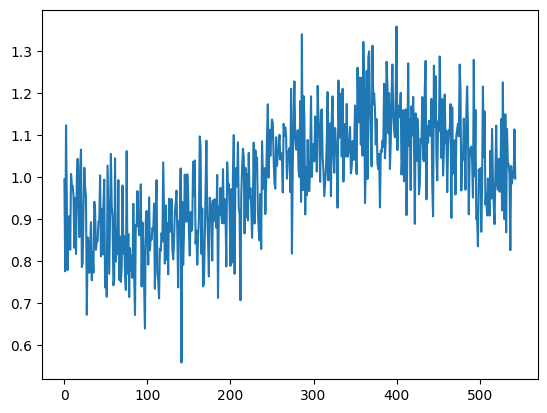

In [30]:
rng = np.random.default_rng()

size = 544

period = rng.uniform(0, 10 * size)
a = rng.uniform(0.05, 0.95)
b = 2 * np.pi / period
c = rng.uniform(0, 10 * size)

print(a, b, c)

scale_factor = 1 + a * np.sin( b * (np.arange(size) - c) )
noise = rng.normal(loc=0, scale=0.1, size=size)

cpu = scale_factor + noise

plt.plot(cpu)

# Fake Network Control Data

Experimenting with generating different aspects of army control demo data (network topo, nodes, task requests, etc).

## Exploring Current Data

Just seeing what the network topo in the CSV looks like.

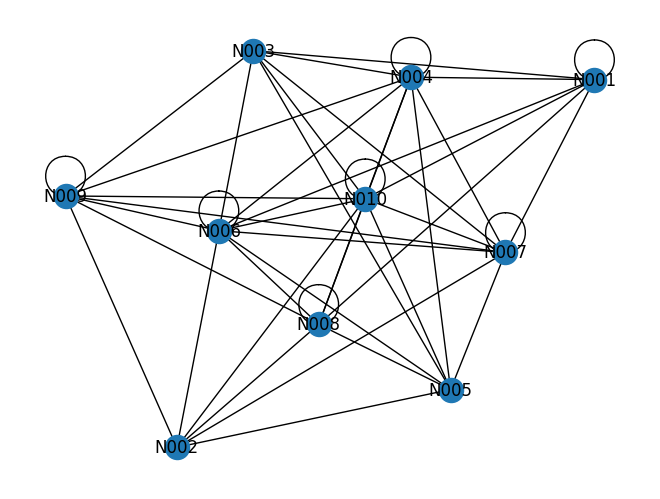

In [30]:
node_path = "dummy_data/nodes.csv"
edge_path = "dummy_data/edges.csv"
nodes = load_nodes(node_path)
edges = load_edges(edge_path)
network = NetworkTopology(nodes.values(), edges.values())
nx.draw(network._graph, with_labels=True)

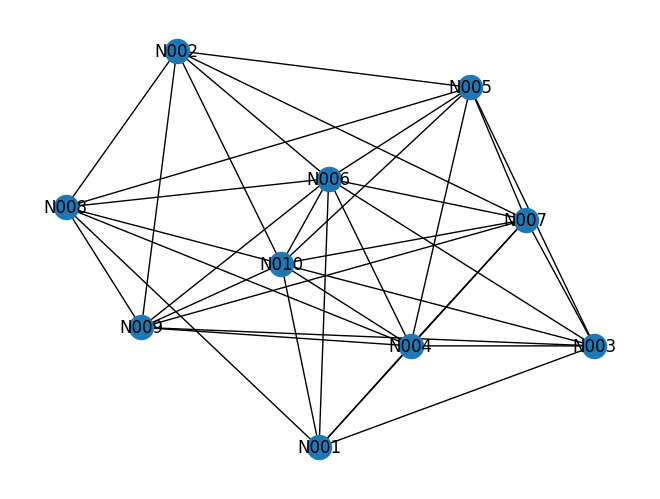

In [46]:
res = nx.Graph()
for n in network._graph.nodes:
    res.add_node(n)
for n1, n2 in combinations(res.nodes, 2):
    path = nx.shortest_path(network._graph, n1, n2)
    nx.add_path(res, path)
nx.draw(res, with_labels=True)

## Serialization

In [2]:
def serialize_jsonl(data: list, path: str):
    with jsonlines.open(path, 'w') as writer:
        if data:
            data_type = type(data[0])
            data = unstructure(data, list[data_type])
            writer.write_all(data)

def deserialize_jsonl(path: str, data_type):
    data = []
    with jsonlines.open(path, 'r') as reader:
        for record in reader:
            data.append(structure(record, data_type))
    return data

## Generate Fake Network Topo

Generate a fake compute cluster, with node and link information.

31.0


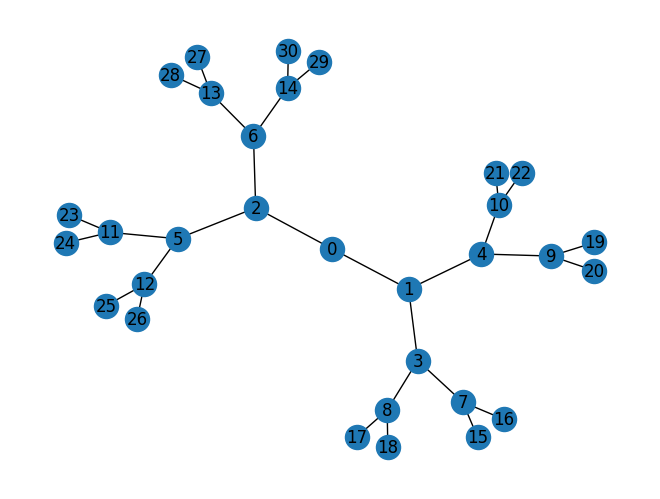

In [3]:
# Generate basic topology for network. Sparse to mimic edge network.
r = 2
h = 4
num_nodes = (r ** (h + 1) - 1) / (r - 1)
print(num_nodes)

graph = nx.balanced_tree(r, h)
nx.draw(graph, with_labels=True)

In [24]:
# Generate node specs.
import random

# Each node can be one of 4 tiers of CPU + memory.
cpu_options = [2, 4, 8, 16]
memory_options = [8, 16, 32, 64]

cpu_specs = random.choices(cpu_options, weights=reversed(cpu_options), k=len(graph.nodes))
mem_specs = [4 * cpu for cpu in cpu_specs]

gen_nodes = []
# Random resource usages.
for i, (cpu, memory) in enumerate(zip(cpu_specs, mem_specs)):
    n_id = f'N{i:03}'
    node = Node(node_id=n_id, cpu_capacity=cpu, memory_capacity=memory)
    gen_nodes.append(node)
    print(node)
    
# Tiered network topology.
# for i, layer in enumerate(nx.bfs_layers(graph, [0])):
#     for n in layer:
#         n_id = f'N{n:03}'

#         idx = min(i, len(cpu_options) - 1)
#         cpu = cpu_options[idx]
#         memory = memory_options[idx]
        
#         node = Node(node_id=n_id, cpu_capacity=cpu, memory_capacity=memory)
#         print(node)
#         gen_nodes.append(node)
#     print(layer)

Node(node_id='N000', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N001', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N002', cpu_capacity=8, memory_capacity=32, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N003', cpu_capacity=16, memory_capacity=64, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N004', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N005', cpu_capacity=2, memory_capacity=8, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N006', cpu_capacity=2, memory_capacity=8, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N007', cpu_capacity=2, memory_capacity=8, network_capacity=None, used_cpu=0.0, used_

In [25]:
# Generate edges.
bandwidth = 100 # Set to fixed mbps for now.

gen_edges = []
for u, v in graph.edges:
    u_id = f'N{u:03}'
    v_id = f'N{v:03}'
    edge = Edge(edge_id=(u_id, v_id), capacity=bandwidth)
    gen_edges.append(edge)
    print(edge)

Edge(edge_id=('N000', 'N001'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N000', 'N002'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N003'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N004'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N005'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N006'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N007'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N008'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N009'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N010'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N011'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N012'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N013'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N014'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N015'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N0

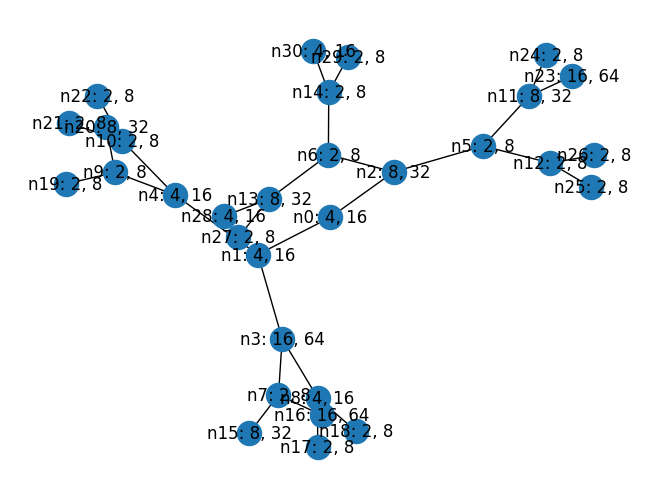

In [26]:
# View generated topo with associated CPU/memory count.
gen_graph = graph.copy(as_view=False)
nx.set_node_attributes(gen_graph, {i: node for i, node in enumerate(gen_nodes)}, 'data')
labels = {i: f'n{i}: {node.cpu_capacity}, {node.memory_capacity}' for i, node in enumerate(gen_nodes)}
nx.draw(gen_graph, with_labels=True, labels=labels)

## Generating Task Information

Tasks can either be independent, or have communication dependencies between each other, so we must generate various task "graphs".

Num Tasks: 248


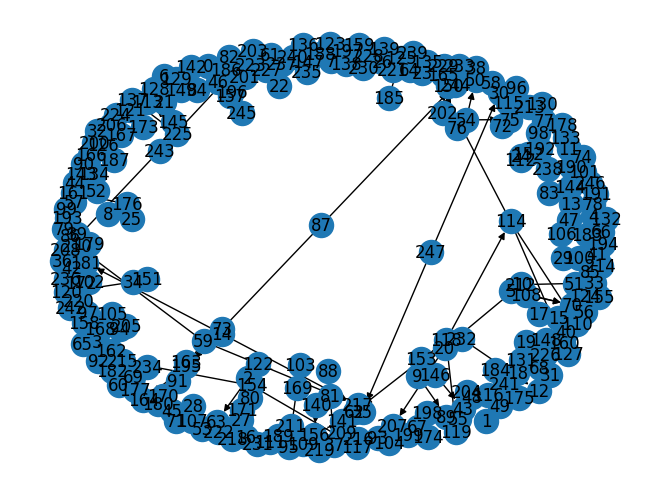

In [27]:
# Generate task graphs.
num_tasks = int(num_nodes * 8)
print(f'Num Tasks: {num_tasks}')
# Number of edges should scale linearly with nodes -> maintains sparsity.
frac = (num_tasks / num_tasks ** 2) / 4
task_graph = nx.fast_gnp_random_graph(num_tasks, p=frac, directed=True)
nx.draw(task_graph, with_labels=True)

In [28]:
# Visualize different task graphs.
comps = list(nx.weakly_connected_components(task_graph))
num_comps = 0
for comp in comps:
    num_comps += 1
    print(comp)
num_comps

{0}
{1}
{2, 122, 63}
{3}
{4}
{5, 70, 10, 108, 207, 20}
{6}
{7}
{8, 25}
{135, 9, 14, 23, 30, 160, 35, 180, 181, 59, 62, 73, 210, 217, 89, 247, 110, 114, 118, 119}
{11}
{232, 12}
{13}
{15}
{16}
{17, 212, 33}
{18}
{19}
{21}
{61, 22}
{24, 112, 152, 192}
{26}
{27}
{28}
{100, 29}
{31}
{32}
{120, 34, 151}
{36}
{88, 81, 37}
{38}
{86, 39}
{40}
{41}
{42}
{153, 146, 43}
{44}
{45}
{245, 46}
{47}
{48, 204}
{49, 116}
{72, 75, 76, 50, 54}
{51}
{52}
{53}
{55}
{56}
{57}
{58}
{60}
{64}
{65}
{66}
{67}
{68}
{69}
{71}
{74, 238}
{77}
{78}
{79}
{80, 171}
{82}
{83, 246}
{84}
{85}
{195, 164, 163, 202, 244, 150, 87}
{90}
{91}
{92}
{93}
{205, 94}
{169, 103, 95}
{96}
{97}
{98}
{99}
{101}
{172, 102}
{104}
{105, 158}
{106}
{107}
{109}
{111}
{113, 145}
{115}
{154, 117, 215}
{121}
{123}
{124}
{185, 125}
{126}
{127}
{128}
{129}
{130}
{131}
{132}
{133}
{134}
{136}
{137, 225}
{138}
{139}
{156, 140}
{141}
{142}
{143}
{144}
{147}
{148}
{149}
{155}
{196, 157}
{159}
{176, 161}
{162}
{165}
{166}
{167}
{168}
{170}
{173}
{174}

175

In [29]:
import time


def make_peer_bws(graph: nx.DiGraph, node: int):
    peer_bws = {}
    rng = np.random.default_rng()
    for n in graph.neighbors(node):
        peer_id = f'T{n:03}'
        peer_bws[peer_id] = np.clip(rng.exponential(3) + 1, 1, 100)
    return peer_bws


def process_comp(task_graph: nx.DiGraph, comp: list[int], arrival_time: int = 0) -> list[Task]:
    rng = np.random.default_rng()
    tasks = []
    for v in comp:
        task_id = f'T{v:03}'
        
        cpu = np.clip(rng.rayleigh(4), 0, 16)
        memory = np.clip(rng.rayleigh(16), 0, 64)
        offset = max(0, arrival_time)
        peer_bws = make_peer_bws(task_graph, v)
        duration = rng.uniform(3 * 60, 15 * 60)
                                 
        task = Task(
            task_id=task_id,
            arrival_offset_s=offset,
            initial_cpu=cpu,
            initial_memory=memory,
            peer_bandwidths=peer_bws,
            duration_s=duration
        )
        tasks.append(task)
    return tasks

In [30]:
# Generate task specs for task graph.
interval = 30
rng = np.random.default_rng()

tasks = []
comp_idx = []
curr_time = 0
# Limit the number of tasks that arrive at the same time.
max_tasks_per_epoch = 60
num_tasks = 0
for i, comp in enumerate(comps):
    out = process_comp(task_graph, comp, arrival_time=curr_time)
    tasks += out
    num_tasks += len(comp)
    comp_idx += [i] * len(out)
    
    if num_tasks > max_tasks_per_epoch:
        curr_time += interval
        num_tasks = 0
    
    print(f'COMP {i}:\n')
    for task in out:
        print(task)
    print()

COMP 0:

Task(task_id='T000', arrival_offset_s=0, duration_s=662.976717353961, initial_cpu=np.float64(5.474832317817067), initial_memory=np.float64(8.292726452396517), peer_bandwidths={})

COMP 1:

Task(task_id='T001', arrival_offset_s=0, duration_s=564.5833391145288, initial_cpu=np.float64(2.1363982680573392), initial_memory=np.float64(39.40624579474508), peer_bandwidths={})

COMP 2:

Task(task_id='T002', arrival_offset_s=0, duration_s=795.1405302440038, initial_cpu=np.float64(10.144845598360456), initial_memory=np.float64(22.79196352942692), peer_bandwidths={'T063': np.float64(1.7686601311129366)})
Task(task_id='T122', arrival_offset_s=0, duration_s=378.0101305184588, initial_cpu=np.float64(5.466385085351219), initial_memory=np.float64(16.848748401828143), peer_bandwidths={'T002': np.float64(1.8963856714447564)})
Task(task_id='T063', arrival_offset_s=0, duration_s=333.72288428949605, initial_cpu=np.float64(1.8615946007126332), initial_memory=np.float64(14.011135375755291), peer_bandw

In [31]:
# Visualize arrival times for different tasks in the format: task id, task graph (component) idx, arrival time offset (s)
for comp_i, t in sorted(zip(comp_idx, tasks), key=lambda x: x[1].arrival_offset_s):
    print(t.task_id, comp_i, t.arrival_offset_s)

T000 0 0
T001 1 0
T002 2 0
T122 2 0
T063 2 0
T003 3 0
T004 4 0
T005 5 0
T070 5 0
T010 5 0
T108 5 0
T207 5 0
T020 5 0
T006 6 0
T007 7 0
T008 8 0
T025 8 0
T135 9 0
T009 9 0
T014 9 0
T023 9 0
T030 9 0
T160 9 0
T035 9 0
T180 9 0
T181 9 0
T059 9 0
T062 9 0
T073 9 0
T210 9 0
T217 9 0
T089 9 0
T247 9 0
T110 9 0
T114 9 0
T118 9 0
T119 9 0
T011 10 0
T232 11 0
T012 11 0
T013 12 0
T015 13 0
T016 14 0
T017 15 0
T212 15 0
T033 15 0
T018 16 0
T019 17 0
T021 18 0
T061 19 0
T022 19 0
T024 20 0
T112 20 0
T152 20 0
T192 20 0
T026 21 0
T027 22 0
T028 23 0
T100 24 0
T029 24 0
T031 25 0
T032 26 30
T120 27 30
T034 27 30
T151 27 30
T036 28 30
T088 29 30
T081 29 30
T037 29 30
T038 30 30
T086 31 30
T039 31 30
T040 32 30
T041 33 30
T042 34 30
T153 35 30
T146 35 30
T043 35 30
T044 36 30
T045 37 30
T245 38 30
T046 38 30
T047 39 30
T048 40 30
T204 40 30
T049 41 30
T116 41 30
T072 42 30
T075 42 30
T076 42 30
T050 42 30
T054 42 30
T051 43 30
T052 44 30
T053 45 30
T055 46 30
T056 47 30
T057 48 30
T058 49 30
T060 50 3

## Serialize Data

Save as JSONL so we can have nested data structures.

In [32]:
task_gen_path = 'tasks.jsonl'
sorted_data = sorted(tasks, key=lambda x: x.arrival_offset_s)
serialize_jsonl(sorted_data, task_gen_path)

In [33]:
node_gen_path = 'nodes.jsonl'
serialize_jsonl(gen_nodes, node_gen_path)

In [34]:
edge_gen_path = 'edges.jsonl'
serialize_jsonl(gen_edges, edge_gen_path)